In [ ]:
# CUSTOMER SEGMENTATION & RFM INTELLIGENCE PIPELINE

In [1]:
import pandas as pd                                     # IMPORT LIBRARIES
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score
)

from sklearn.neighbors import NearestNeighbors

from sklearn.mixture import GaussianMixture

from sklearn.ensemble import RandomForestClassifier

import shap

In [2]:
data = pd.read_csv(              # CONVERT DATE

    r"C:\Users\sabsm\Documents\Amdex DS Group Project Materials\cleaned_online_retail.csv\cleaned_online_retail.csv",

    low_memory=False
)

In [3]:
data["InvoiceDate"] = pd.to_datetime(

    data["InvoiceDate"]
)

In [4]:
def categorize_product(desc):                          # CREATE PRODUCT CATEGORIES

    desc = str(desc).lower()

    # Storage & Bags
    if (
        "bag" in desc or
        "basket" in desc or
        "box" in desc
    ):
        return "Storage & Bags"

    # Kitchen
    elif (
        "glass" in desc or
        "jar" in desc or
        "plate" in desc or
        "bowl" in desc or
        "kitchen" in desc or
        "mug" in desc or
        "cup" in desc
    ):
        return "Kitchen"

    # Home Decor
    elif (
        "heart" in desc or
        "holder" in desc or
        "candle" in desc or
        "decor" in desc or
        "vase" in desc
    ):
        return "Home Decor"

    # Kids
    elif (
        "toy" in desc or
        "child" in desc or
        "kids" in desc or
        "doll" in desc
    ):
        return "Kids"

    # Seasonal
    elif (
        "christmas" in desc or
        "xmas" in desc or
        "holiday" in desc
    ):
        return "Seasonal"

    # Stationery
    elif (
        "pen" in desc or
        "paper" in desc or
        "card" in desc or
        "notebook" in desc
    ):
        return "Stationery"

    # Lighting
    elif (
        "light" in desc or
        "lamp" in desc
    ):
        return "Lighting"

    # Textile
    elif (
        "fabric" in desc or
        "blanket" in desc or
        "cushion" in desc
    ):
        return "Textile"

    # Photo & Frames
    elif (
        "frame" in desc or
        "photo" in desc
    ):
        return "Photo & Frames"

    # Clocks
    elif (
        "clock" in desc
    ):
        return "Clocks"

    # Garden
    elif (
        "flower" in desc or
        "garden" in desc
    ):
        return "Garden"

    # Furniture & Decor
    elif (
        "wooden" in desc or
        "metal" in desc
    ):
        return "Furniture & Decor"

    else:
        return "Other"

In [6]:
data["Category"] = data["Description"].apply(              # APPLY CATEGORY

    categorize_product
)

In [7]:
print(                                # CHECK CATEGORY DISTRIBUTION

    data["Category"].value_counts()
)

Category
Other                383526
Storage & Bags       153484
Home Decor           134104
Kitchen               93787
Stationery            69058
Furniture & Decor     41245
Seasonal              32518
Kids                  31991
Garden                19732
Lighting              17389
Photo & Frames        13143
Clocks                 9606
Textile                8331
Name: count, dtype: int64


In [8]:
reference_date = (                              # CREATE RFM FEATURES

    data["InvoiceDate"].max()

    + pd.Timedelta(days=1)
)


rfm = data.groupby(

    "CustomerID"

).agg({

    "InvoiceDate":
        lambda x:
        (reference_date - x.max()).days,

    "InvoiceNo": "nunique",

    "Revenue": "sum"
})


rfm.columns = [

    "Recency",

    "Frequency",

    "Monetary"
]


rfm = rfm.reset_index()

In [9]:
customer_category = data.groupby(                 # ADD DOMINANT CATEGORY PER CUSTOMER

    "CustomerID"

)["Category"].agg(

    lambda x:
    x.mode()[0]
)


rfm = pd.merge(

    rfm,

    customer_category,

    on="CustomerID"
)


In [10]:
rfm_encoded = pd.get_dummies(           # ONE-HOT ENCODE CATEGORY

    rfm,

    columns=["Category"]
)

In [11]:
scaler = StandardScaler()                  # FEATURE SCALING

scaled_features = scaler.fit_transform(

    rfm_encoded.drop(
        columns=["CustomerID"]
    )
)

In [12]:
k_values = range(6,11)                          # KMEANS ANALYSIS

wcss = []

silhouette_scores = []

db_scores = []


for k in k_values:

    kmeans = KMeans(

        n_clusters=k,

        n_init=10,

        random_state=42
    )

    labels = kmeans.fit_predict(
        scaled_features
    )

    # WCSS
    wcss.append(
        kmeans.inertia_
    )

    # Silhouette
    silhouette_scores.append(

        silhouette_score(
            scaled_features,
            labels
        )
    )

    # Davies-Bouldin
    db_scores.append(

        davies_bouldin_score(
            scaled_features,
            labels
        )
    )

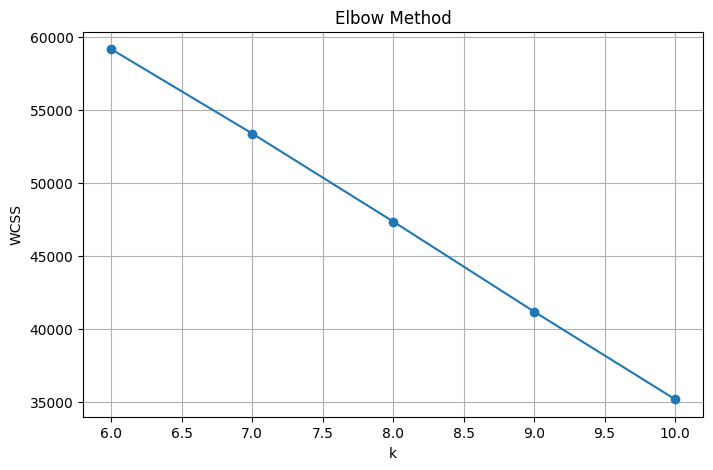

In [13]:
plt.figure(figsize=(8,5))                # ELBOW PLOT

plt.plot(

    k_values,

    wcss,

    marker='o'
)

plt.title("Elbow Method")

plt.xlabel("k")

plt.ylabel("WCSS")

plt.grid(True)

plt.show()

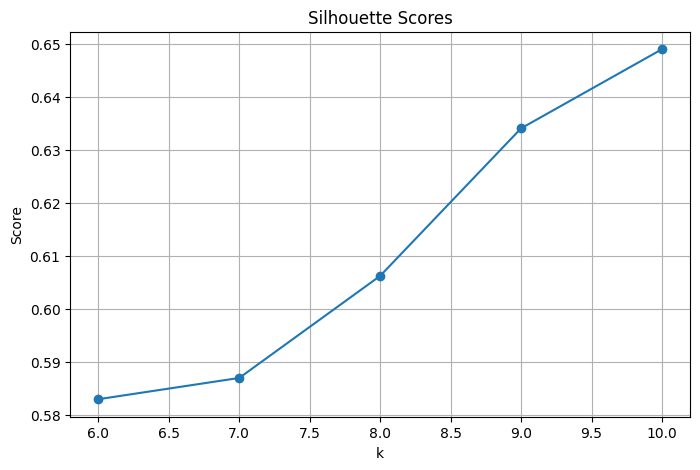

In [14]:
plt.figure(figsize=(8,5))                         # SILHOUETTE PLOT

plt.plot(

    k_values,

    silhouette_scores,

    marker='o'
)

plt.title("Silhouette Scores")

plt.xlabel("k")

plt.ylabel("Score")

plt.grid(True)

plt.show()

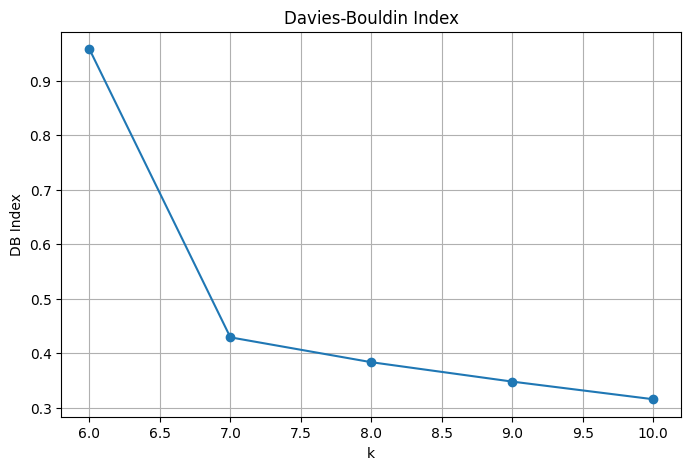

In [15]:
plt.figure(figsize=(8,5))                  # DAVIES-BOULDIN PLOT

plt.plot(

    k_values,

    db_scores,

    marker='o'
)

plt.title("Davies-Bouldin Index")

plt.xlabel("k")

plt.ylabel("DB Index")

plt.grid(True)

plt.show()

In [16]:
final_k = k_values[            # FINAL K SELECTION

    np.argmin(db_scores)
]

print("Best k:", final_k)

Best k: 10


In [17]:
kmeans = KMeans(                                # FINAL KMEANS MODEL

    n_clusters=final_k,

    n_init=10,

    random_state=42
)

rfm_encoded["KMeans_Cluster"] = kmeans.fit_predict(

    scaled_features
)

In [18]:
neighbors = NearestNeighbors(                         # DBSCAN - AUTO EPS

    n_neighbors=5
)

neighbors_fit = neighbors.fit(

    scaled_features
)

distances, indices = neighbors_fit.kneighbors(

    scaled_features
)

distances = np.sort(

    distances[:,4]
)

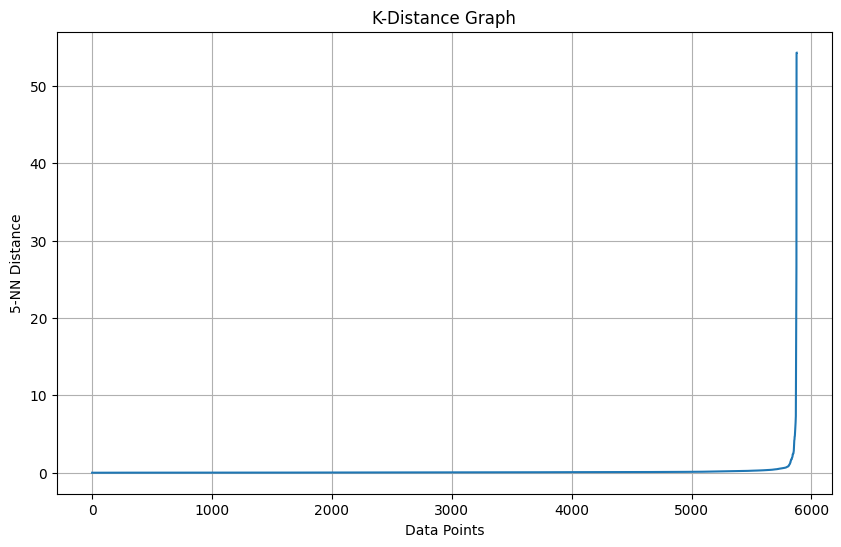

In [19]:
plt.figure(figsize=(10,6))          # K-DISTANCE GRAPH

plt.plot(distances)

plt.title("K-Distance Graph")

plt.xlabel("Data Points")

plt.ylabel("5-NN Distance")

plt.grid(True)

plt.show()

In [20]:
eps = 1.5            # SET EPS FROM GRAPH

In [21]:
dbscan = DBSCAN(                                         # DBSCAN MODEL
 
    eps=eps,

    min_samples=5
)

rfm_encoded["DBSCAN_Cluster"] = dbscan.fit_predict(

    scaled_features
)

In [22]:
outliers = rfm_encoded[                     # OUTLIERS / ULTRA VIPS

    rfm_encoded["DBSCAN_Cluster"] == -1
]

In [23]:
rfm_encoded["CLV"] = (             # CLV ESTIMATION

    rfm_encoded["Monetary"]

    * rfm_encoded["Frequency"]

    * 12
)

In [24]:
vip_customers = rfm_encoded[               # VIP CUSTOMERS

    rfm_encoded["CLV"]

    > rfm_encoded["CLV"].quantile(0.99)
]

In [25]:
gmm = GaussianMixture(          # GMM MODEL

    n_components=final_k,

    random_state=42
)

gmm.fit(scaled_features)

GaussianMixture(n_components=10, random_state=42)

In [26]:
probabilities = gmm.predict_proba(              # GMM PROBABILITIES

    scaled_features
)


rfm_encoded["GMM_Cluster"] = gmm.predict(

    scaled_features
)

In [27]:
rfm_encoded["Max_Probability"] = (              # BORDERLINE CUSTOMERS

    probabilities.max(axis=1)
)


borderline_customers = rfm_encoded[

    rfm_encoded["Max_Probability"] < 0.60
]

In [28]:
rfm_encoded["Churn"] = np.where(            # CHURN LABEL

    rfm_encoded["Recency"] > 90,

    1,

    0
)

In [29]:
X = rfm_encoded.drop(                 # CHURN MODEL

    columns=[

        "CustomerID",

        "Churn"
    ]
)

y = rfm_encoded["Churn"]


model = RandomForestClassifier(

    random_state=42
)

model.fit(X, y)

RandomForestClassifier(random_state=42)

In [30]:
rfm_encoded["Churn_Probability"] = (               # CHURN PROBABILITY

    model.predict_proba(X)[:,1]
)

In [34]:
import shap                                 # SHAP EXPLAINABILITY

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X)


# FOR BINARY CLASSIFICATION
# USE POSITIVE CLASS

if isinstance(shap_values, list):

    shap_matrix = shap_values[1]

else:

    shap_matrix = shap_values

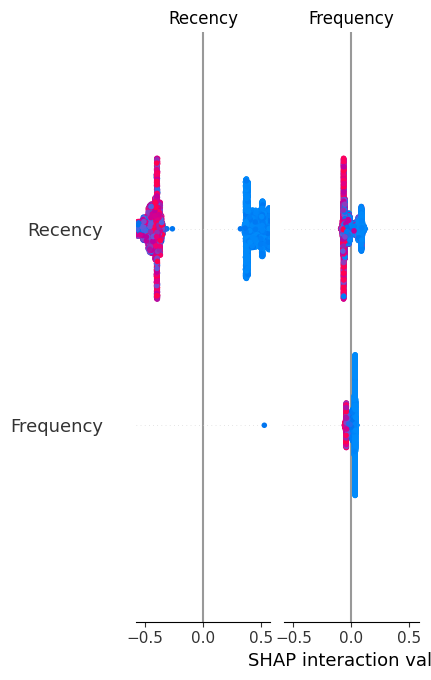

In [35]:
shap.summary_plot(         # SHAP SUMMARY PLOT

    shap_matrix,

    X
)

In [36]:
def retention_action(row):            # CRM RETENTION ACTIONS

    if row["CLV"] > 50000:

        return "VIP_RETENTION"

    elif row["Recency"] > 180:

        return "WINBACK_CAMPAIGN"

    elif row["Frequency"] < 3:

        return "REENGAGEMENT"

    else:

        return "LOYALTY_PROGRAM"


rfm_encoded["Retention_Action"] = rfm_encoded.apply(

    retention_action,

    axis=1
)

In [37]:
segment_profile = rfm_encoded.groupby(                # SEGMENT PROFILING

    "KMeans_Cluster"

).agg({

    "Monetary": "mean",

    "Frequency": "mean",

    "Recency": "mean",

    "CLV": "mean",

    "Churn_Probability": "mean"
})


print(segment_profile)

                   Monetary  Frequency     Recency           CLV  \
KMeans_Cluster                                                     
0               3425.978799   6.966315  186.825619  2.065081e+06   
1                932.736667   3.168950  284.712329  1.401936e+05   
2                706.362667   2.022222  176.911111  2.513281e+04   
3               3487.958889   7.371212  195.578283  1.281708e+06   
4                930.887398   3.474576  255.788906  8.539984e+04   
5               1431.117391   3.478261  262.782609  1.301390e+05   
6                872.425352   2.985915  242.492958  1.402009e+05   
7                365.690000   1.531250  295.531250  7.702061e+03   
8               1545.909322   4.000000  241.288136  1.787615e+05   
9                231.543500   1.600000  369.950000  6.939978e+03   

                Churn_Probability  
KMeans_Cluster                     
0                        0.477798  
1                        0.716256  
2                        0.442889  
3  

In [38]:
segment_revenue = rfm_encoded.groupby(            # REVENUE CONTRIBUTION

    "KMeans_Cluster"

)["Monetary"].sum()


revenue_percent = (

    segment_revenue

    / segment_revenue.sum()

    * 100
)


print(revenue_percent)

KMeans_Cluster
0    86.049726
1     1.175664
2     0.182945
3     7.949625
4     3.477138
5     0.189445
6     0.356506
7     0.067351
8     0.524948
9     0.026653
Name: Monetary, dtype: float64


In [39]:
category_affinity = pd.crosstab(              # CATEGORY AFFINITY

    rfm_encoded["KMeans_Cluster"],

    rfm["Category"],

    normalize="index"
)


print(category_affinity)

Category          Clocks  Furniture & Decor  Garden  Home Decor  Kids  \
KMeans_Cluster                                                          
0               0.004125                0.0     0.0         0.0   0.0   
1               0.000000                0.0     0.0         0.0   0.0   
2               0.000000                0.0     0.0         0.0   0.0   
3               0.000000                0.0     0.0         0.0   0.0   
4               0.000000                0.0     0.0         1.0   0.0   
5               0.000000                0.0     0.0         0.0   0.0   
6               0.000000                0.0     0.0         0.0   0.0   
7               0.000000                0.0     0.0         0.0   1.0   
8               0.000000                1.0     0.0         0.0   0.0   
9               0.000000                0.0     1.0         0.0   0.0   

Category        Kitchen  Lighting     Other  Photo & Frames  Seasonal  \
KMeans_Cluster                                    

In [40]:
crm_export = rfm_encoded[                      # HIGH CHURN CRM EXPORT

    rfm_encoded["Churn_Probability"] > 0.75
]


In [41]:
rfm_encoded.to_csv(                 # EXPORT FILES

    "dashboard_master.csv",

    index=False
)

crm_export.to_csv(

    "crm_retention_export.csv",

    index=False
)

segment_profile.to_csv(

    "segment_profile.csv"
)

category_affinity.to_csv(

    "category_affinity.csv"
)

In [42]:
print("\nPipeline Completed Successfully")           # FINAL OUTPUTS

print("\nFiles Exported:")

print("dashboard_master.csv")

print("crm_retention_export.csv")

print("segment_profile.csv")

print("category_affinity.csv")


Pipeline Completed Successfully

Files Exported:
dashboard_master.csv
crm_retention_export.csv
segment_profile.csv
category_affinity.csv
